In [1]:
import tensorflow as tf
import  matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
x_train=pd.read_csv("emnist-letters-train.csv")
x_test=pd.read_csv("emnist-letters-test.csv")

In [3]:
y1 = np.array(x_train.iloc[:,0].values)
x1 = np.array(x_train.iloc[:,1:].values)
#testing_labels
y2 = np.array(x_test.iloc[:,0].values)
x2 = np.array(x_test.iloc[:,1:].values)
print(y1.shape)
print(x1.shape)

(88799,)
(88799, 784)


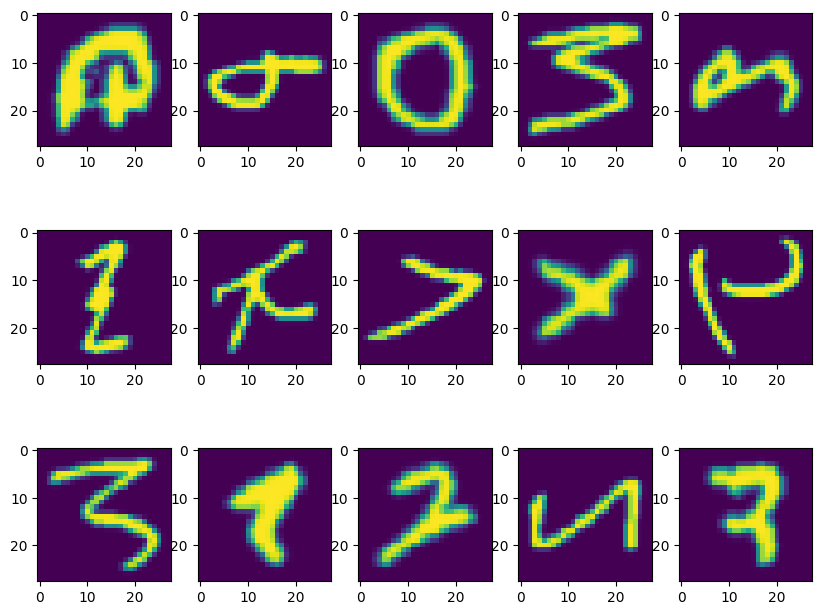

In [4]:
import matplotlib.pyplot as plt 
fig,axes = plt.subplots(3,5,figsize=(10,8))
for i,ax in enumerate(axes.flat):
    ax.imshow(x1[i].reshape([28,28]))

In [5]:
print(f"Training data shape: {x_train.shape}")
print(f"Testing data shape: {x_test.shape}")

Training data shape: (88799, 785)
Testing data shape: (14799, 785)


In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau,ModelCheckpoint
from sklearn.model_selection import train_test_split

In [7]:
train_x,test_x,train_y,test_y = train_test_split(x_train,y1,test_size=0.2,random_state = 42)

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential # thise is used for 
from tensorflow.keras.layers import Dense,Flatten,Input # this is used for creating layers   
from tensorflow.keras.datasets import mnist #   thise is used for loading the dataset
from tensorflow.keras.utils import to_categorical #this is used for one hot encoding

In [9]:
#load data sets
(x_train ,y_train), (x_test ,y_test) = mnist.load_data()
#normalize
x_train = x_train / 255
x_test = x_test / 255
#one hot encode
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [10]:
#building simple neural network
model = Sequential([
    #Flatten(input_shape=(28,28)),
    Input(shape=(28,28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

In [11]:
#compiling the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [12]:
model.fit(x_train, y_train, epochs=5, batch_size=32)
#evalute model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc*100:.4f}")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9269 - loss: 0.2556
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9677 - loss: 0.1093
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9764 - loss: 0.0769
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9821 - loss: 0.0580
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9858 - loss: 0.0448
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9756 - loss: 0.0764
Test accuracy: 97.5600
